# Homework 1 — Number of hidden layers

**Question:** does a deeper network help? The evidence says the models under-fit rather than over-fit: training RMSLE
stays at ~0.83 ([mlp.ipynb](mlp.ipynb)), regularization only hurts
([regularization_test.ipynb](regularization_test.ipynb)), and validation still improves at epoch 20
([epochs_test.ipynb](epochs_test.ipynb)). So more capacity might help.

**Setup:** mlp_4out_emb and mlp_4out_mean with 2 (current), 3 and 4 hidden layers of 64 units (BatchNorm, ReLU), Adam,
20 epochs. The same 4 seasonal folds as every notebook (2M training / 500K validation rows each).

**Rule, fixed before running:** a deeper network replaces the current one only if its fold-average validation RMSLE is
lower by more than 0.01 (the seed noise level) and it's better on at least 3 of 4 folds.

In [1]:
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, "..")  # the ashrae package lives in the homework folder
from ashrae.config import FOLDS
from ashrae.data import read_processed, split
from ashrae.features import add_series_mean, build_features
from ashrae.metrics import rmsle
from ashrae.modeling import MeterMLP, make_loaders, predict
from ashrae.plots import plot_curves
from ashrae.tracking import Experiment

EPOCHS = 20
N_TRAIN, N_VAL = 2_000_000, 500_000  # rows sampled per fold, as in the other notebooks
DEPTHS = [2, 3, 4]  # hidden layers
experiment = Experiment("ashrae-layers")

2026/09/27 18:58:10 INFO mlflow.tracking.fluent: Experiment with name 'ashrae-layers' does not exist. Creating a new experiment.


MLflow: sqlite:////Users/lupaskodmitro/FuckIT/Machine Learning/Deep Learning Course/Homeworks/Homework 1/mlflow.db, experiment 'ashrae-layers', session 2026-09-27 18:58:10


## Data

Same folds, rows and features as [optimizers_test.ipynb](optimizers_test.ipynb): mlp_4out_mean gets the series mean
as an extra input, mlp_4out_emb a 16-number building embedding. Anomalies are dropped from training only.

In [2]:
df = read_processed()
n_buildings = int(df.building_id.max()) + 1


def fold_data(val_months):
    train_df, val_df = split(df, val_months, N_TRAIN, N_VAL)
    year_median = train_df.year_built.median()
    X_train, X_val = build_features(train_df, year_median), build_features(val_df, year_median)
    return {
        "mlp_4out_mean": make_loaders(train_df, val_df, add_series_mean(X_train, train_df, train_df),
                                      add_series_mean(X_val, val_df, train_df))[:2],
        "mlp_4out_emb": make_loaders(train_df, val_df, X_train, X_val)[:2],
        "anomaly": val_df.anomaly.to_numpy(),
    }


folds = {name: fold_data(months) for name, months in FOLDS.items()}
n_features = folds["Jan–Mar"]["mlp_4out_emb"][0].dataset.x.shape[1]
del df
MODELS = {
    "mlp_4out_mean": lambda n_layers: MeterMLP(n_features + 1, n_layers=n_layers),
    "mlp_4out_emb": lambda n_layers: MeterMLP(n_features, n_buildings, n_layers=n_layers),
}

## Models

`MeterMLP` with `n_layers` hidden layers ([ashrae/modeling.py](../ashrae/modeling.py)); each extra layer adds
64 × 64 weights plus BatchNorm, ~4K parameters.

In [3]:
pd.DataFrame({model: {depth: sum(p.numel() for p in make(depth).parameters()) for depth in DEPTHS}
              for model, make in MODELS.items()}).rename_axis("hidden layers")

,mlp_4out_mean,mlp_4out_emb
hidden layers,,
2,6916,31060
3,11204,35348
4,15492,39636


## Training

24 runs: 2 models × 3 depths × 4 folds, logged to MLflow with per-epoch training and validation RMSLE. After the last
epoch, validation is also scored on clean rows (without anomalies).

In [4]:
results = []
for fold, data in folds.items():
    for model_name, make in MODELS.items():
        train_loader, val_loader = data[model_name]
        y, anomaly = val_loader.dataset.y.numpy(), data["anomaly"]
        for depth in DEPTHS:
            model, run_id = experiment.fit(lambda: make(depth), train_loader, val_loader,
                                           run_name=f"{model_name} | {depth} layers | {fold}", epochs=EPOCHS,
                                           tags={"model": model_name, "layers": depth, "fold": fold})
            pred = predict(model, val_loader)
            val_curve = experiment.history(run_id, "val_rmsle")
            results.append({"fold": fold, "model": model_name, "layers": depth, "val_curve": val_curve,
                            "val_all": val_curve[-1], "val_clean": rmsle(y[~anomaly], pred[~anomaly]),
                            "train": experiment.history(run_id, "train_rmsle")[-1]})
            print(f"{fold} {model_name:14s} {depth} layers: val {val_curve[-1]:.3f} "
                  f"(clean {results[-1]['val_clean']:.3f}), train {results[-1]['train']:.3f}")
results = pd.DataFrame(results)

Jan–Mar mlp_4out_mean  2 layers: val 1.451 (clean 0.966), train 0.872


Jan–Mar mlp_4out_mean  3 layers: val 1.445 (clean 0.955), train 0.854


Jan–Mar mlp_4out_mean  4 layers: val 1.443 (clean 0.961), train 0.842


Jan–Mar mlp_4out_emb   2 layers: val 1.418 (clean 0.930), train 0.818


Jan–Mar mlp_4out_emb   3 layers: val 1.422 (clean 0.922), train 0.809


...

Oct–Dec mlp_4out_mean  3 layers: val 1.113 (clean 1.023), train 0.818


Oct–Dec mlp_4out_mean  4 layers: val 1.119 (clean 1.033), train 0.804


Oct–Dec mlp_4out_emb   2 layers: val 1.095 (clean 1.006), train 0.771


Oct–Dec mlp_4out_emb   3 layers: val 1.112 (clean 1.024), train 0.762


Oct–Dec mlp_4out_emb   4 layers: val 1.116 (clean 1.027), train 0.757


## Results

Epoch-20 scores. Difference = deeper − 2 layers: negative means the deeper network is better.

val_all  val_clean  train  val_all − 2 layers  \
model         hidden layers                                                  
mlp_4out_emb  2                1.188      0.925  0.806               0.000   
              3                1.192      0.927  0.797               0.004   
              4                1.192      0.925  0.792               0.004   
mlp_4out_mean 2                1.236      0.982  0.868               0.000   
              3                1.225      0.967  0.848              -0.011   
              4                1.222      0.967  0.834              -0.014   

                             folds better than 2 layers  
model         hidden layers                              
mlp_4out_emb  2                                       0  
              3                                       2  
              4                                       2  
mlp_4out_mean 2                                       0  
              3                                       4  
              4                                       4

fold                         Jan–Mar  Apr–Jun  Jul–Sep  Oct–Dec
model         hidden layers                                    
mlp_4out_emb  2                1.418    1.211    1.027    1.095
              3                1.422    1.208    1.027    1.112
              4                1.421    1.202    1.027    1.116
mlp_4out_mean 2                1.451    1.242    1.126    1.124
              3                1.445    1.235    1.107    1.113
              4                1.443    1.233    1.095    1.119

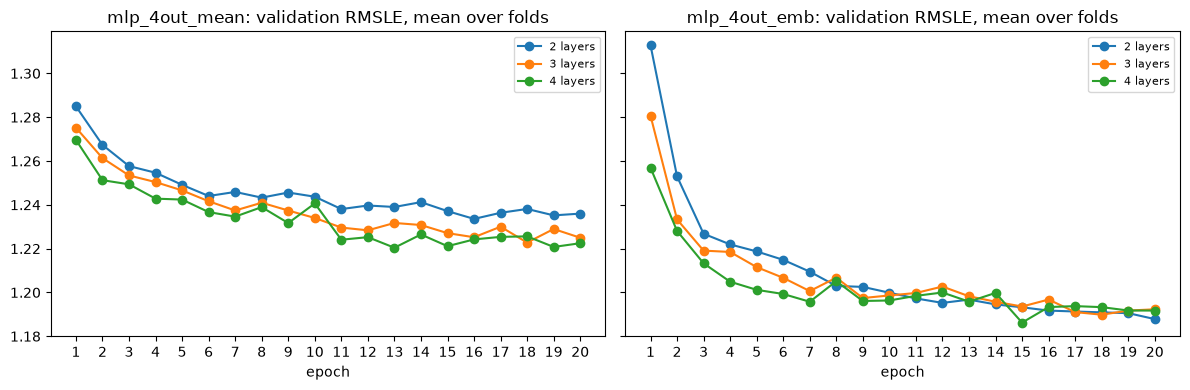

In [5]:
summary = results.groupby(["model", "layers"])[["val_all", "val_clean", "train"]].mean()
summary["val_all − 2 layers"] = summary.val_all - summary.val_all.xs(2, level="layers").reindex(
    summary.index, level="model").to_numpy()
per_fold = results.pivot_table(index=["model", "layers"], columns="fold", values="val_all")[list(FOLDS)]
better_folds = (per_fold.sub(per_fold.xs(2, level="layers"), level="model") < 0).sum(axis=1)
summary["folds better than 2 layers"] = better_folds
display(summary.round(3).rename_axis(["model", "hidden layers"]))
display(per_fold.round(3).rename_axis(["model", "hidden layers"]))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, (model_name, group) in zip(axes, results.groupby("model", sort=False)):
    curves = {f"{depth} layers": np.mean(g.val_curve.tolist(), axis=0).tolist() for depth, g in group.groupby("layers")}
    plot_curves(ax, curves, f"{model_name}: validation RMSLE, mean over folds")
plt.tight_layout()

## Findings

Fold averages at epoch 20, all rows unless noted.

- **mlp_4out_emb: depth doesn't help, so the rule keeps 2 layers.** 1.188 (2 layers), 1.192 (3), 1.192 (4); clean
  rows 0.925–0.927. Deeper networks fit the training rows a little better (0.806 → 0.792) without validating better.
  They only converge faster: lower validation up to epoch ~7, the same from epoch 9 on.
- **mlp_4out_mean: depth helps a little, in every fold.** 1.236 → 1.225 (3 layers) → 1.222 (4), clean rows
  0.982 → 0.967. The 4-layer version passes the rule (−0.014, 4 of 4 folds).
- **The embedding model still wins:** the best mean model (1.222) stays behind the 2-layer embedding model (1.188).
  Extra layers partly make up for what the mean model lacks: the embedding already gives its network 16 learned numbers
  per building to work with, the mean model gets one.
- **So capacity isn't what limits the submitted model.** Its remaining error is the anomaly rows in validation and the
  season ([season_validation.ipynb](../validation/season_validation.ipynb)); more training rows or new features are the
  next things to try, not more layers.

One seed per run; differences below ~0.01 may be noise.